# Does Synthetic Data Help? — Downstream Verdict Study (UWF)

This notebook completes the synthetic-generation experiment. A conditional diffusion generator was
already trained to produce rare-lesion retinal images, **but the generated data was never tested on the
actual task.** That test is the entire point, and it is what this notebook runs.

**The question.** Rare proliferative-DR lesions (NV, VH, RD) are severely under-represented. Does adding
*generated* rare-lesion images to the training set improve a classifier's **recall on those lesions**,
measured on a fixed, **100%-real held-out test set** — and does it beat the naive alternative of simply
**oversampling** the few real rare images?

**Three regimes, one held-out real test set.** The model, loss, and the real validation/test splits are
identical across all three; only the *training* data differs.

| Regime | Training data |
|---|---|
| **i. real** | 7,282 real UWF training images |
| **ii. real + oversample** | same, but real rare-positive images are up-weighted (the baseline to beat) |
| **iii. real + synthetic** | real + ~1,088 generated rare-lesion images |

**Verdict rule.** Regime iii "wins" only if it beats **both** i and ii on mean rare-class recall
**without** regressing grade agreement (quadratic $\kappa$) or common-lesion F1.

---

### Honest caveats (stated up front, printed again in the results)
- **Resolution gap.** The generator produces $64\times64$ images; this study runs at $256\times256$, so
  synthetic images are $4\times$ bilinearly upsampled and are inherently blurrier than the real ones. The
  quality gate (FID/KID at 64 and 256) quantifies this.
- **Single seed (preliminary).** `QUICK_PASS=True` runs one seed and synthetic amount $1\times$. The full
  protocol ($\geq3$ seeds, amounts $\{0.5,1,2\}\times$, Wilcoxon significance) is coded and runs unchanged
  when `QUICK_PASS=False`.
- **Inherited labels.** The generator was conditioned only on a binary *has-rare* flag, so each synthetic
  image inherits the full grade+lesion label of a randomly chosen real rare-positive image.
- A negative result (synthetic does not beat oversampling at $64$px) is a **valid, reportable finding**
  that motivates a higher-resolution generator.

In [24]:
# ==============================================================================
# 0. Environment + optional installs
# ==============================================================================
import os, sys, time, math, glob, json, subprocess, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

def _pip(*a):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a]); return True
    except Exception as e:
        print(f"[warn] pip install {a} failed: {e}"); return False

# torch-fidelity is optional (FID/KID). A torchvision-InceptionV3 FID fallback is defined later.
try:
    import torch_fidelity  # noqa: F401
    HAS_TFID = True
except Exception:
    HAS_TFID = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPU = torch.cuda.device_count()
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available(), "| GPUs:", N_GPU)
for i in range(N_GPU):
    print("  ", i, torch.cuda.get_device_name(i))
print("torch-fidelity available:", HAS_TFID)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

LESION_NAMES = ["MA", "HE", "IH", "VB/IRMA", "NV", "VH", "RD"]
RARE_LESION_IDX = [4, 5, 6]        # NV, VH, RD
COMMON_LESION_IDX = [0, 1, 2, 3]

PyTorch: 2.10.0+cu128 | CUDA: True | GPUs: 2
   0 Tesla T4
   1 Tesla T4
torch-fidelity available: False


In [25]:
# ==============================================================================
# 1. Configuration
# ==============================================================================
QUICK_PASS = True        # True: 1 seed, amount 1x (fits one session). False: 3 seeds x {0.5,1,2}x + Wilcoxon.

CONFIG = {
    # ---- study ----
    "STUDY_RES": 256,             # all regimes train/eval at this resolution
    "GEN_RES": 64,                # generator native resolution
    "GUIDANCE_W": 3.0,            # classifier-free guidance scale used at sampling
    "REGIMES": ["real", "oversample", "synth"],
    "SEEDS": [42] if QUICK_PASS else [42, 43, 44],
    "SYN_AMOUNTS": [1.0] if QUICK_PASS else [0.5, 1.0, 2.0],   # xrare-count; QUICK uses 1x
    # ---- classifier training (folder-3/heads-ablation values) ----
    "epochs": 22,
    "patience": 8,
    "batch_size_per_gpu": 16,
    "num_workers": 4,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "grad_clip": 2.0,
    "afl_gamma": 2.0,
    "afl_beta": [0.7, 0.7, 0.7, 0.8, 0.95, 0.95, 0.95],
    "grade_label_smoothing": 0.05,
    "supcon_temperature": 0.1,
    "lambda_grade": 1.0,
    "lambda_supcon": 0.5,
    "sel_rare_weight": 0.5,       # composite selection = 0.5*mean_rare_recall + 0.5*macro_f1
    "sel_f1_weight": 0.5,
    # ---- split (frozen, identical to the mature experiment) ----
    "test_size": 0.15, "val_size": 0.15, "stratify": True, "split_seed": 42,
    "EXPECTED_SIG": "da1ec8e21f22",
    # ---- thresholds (fit on val only) ----
    "thr_min": 0.05, "thr_max": 0.95, "thr_step": 0.01, "thr_objective": "f1",
    # ---- run control ----
    "TIME_BUDGET_HRS": 10.5,
    "backup_to_dataset": True,
    "backup_dataset_slug": "krrish/checkpoint-smg-downstream",
}
_BASE = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.getcwd()
DIRS = {k: os.path.join(_BASE, k) for k in ("checkpoints", "logs", "results", "plots", "synthetic_pool")}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)
CONFIG["ckpt_dir"] = DIRS["checkpoints"]; CONFIG["OUT_DIR"] = _BASE
CONFIG["batch_size"] = CONFIG["batch_size_per_gpu"] * max(1, N_GPU)
T0 = time.time(); DEADLINE = T0 + CONFIG["TIME_BUDGET_HRS"] * 3600
print(f"QUICK_PASS={QUICK_PASS} | study res {CONFIG['STUDY_RES']} | regimes {CONFIG['REGIMES']} "
      f"| seeds {CONFIG['SEEDS']} | amounts {CONFIG['SYN_AMOUNTS']}")
print("backup ->", CONFIG["backup_dataset_slug"], "| output", _BASE)

QUICK_PASS=True | study res 256 | regimes ['real', 'oversample', 'synth'] | seeds [42] | amounts [1.0]
backup -> krrish1008/checkpoint-smg-downstream | output /kaggle/working


In [26]:
# ==============================================================================
# data/mmrdr_uwf.py -- CSV locate, lesion parse, transforms, dataset, frozen split
# ==============================================================================
import ast, hashlib, cv2
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, ConcatDataset, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split

IMAGENET_MEAN = [0.485, 0.456, 0.406]; IMAGENET_STD = [0.229, 0.224, 0.225]

def find_uwf_csv():
    for pat in ("/kaggle/input/**/UWF.csv", "/kaggle/input/**/MMRDR-UWF/UWF.csv"):
        hits = glob.glob(pat, recursive=True)
        if hits: return hits[0]
    for c in ("../MMRDR/MMRDR-UWF/UWF.csv", "MMRDR/MMRDR-UWF/UWF.csv", "../../MMRDR/MMRDR-UWF/UWF.csv"):
        if os.path.exists(c): return os.path.abspath(c)
    return None

def parse_lesion(s):
    try:
        v = np.array(ast.literal_eval(str(s)), dtype=np.float32)
    except Exception:
        v = np.array([float(x) for x in str(s).strip("[]").split(",") if x.strip()], dtype=np.float32)
    if v.shape[0] != 7:
        v = np.zeros(7, dtype=np.float32)
    return (v > 0).astype(np.float32)

def apply_uwf_mask(pil_img, tightness=0.98):
    img = np.array(pil_img); gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, th = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return pil_img
    c = max(cnts, key=cv2.contourArea)
    if len(c) >= 5:
        e = cv2.fitEllipse(c); se = (e[0], (e[1][0]*tightness, e[1][1]*tightness), e[2])
        mask = np.zeros_like(gray); cv2.ellipse(mask, se, 255, -1)
        return Image.fromarray(cv2.bitwise_and(img, img, mask=mask))
    return pil_img

def build_transforms(res):
    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(0.5), transforms.RandomVerticalFlip(0.5),
        transforms.ColorJitter(0.2, 0.2, 0.2), transforms.RandomRotation(10),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
    eval_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
    return train_tf, eval_tf

# Reading 7k+ large UWF JPEGs from the Kaggle network FS + cv2 masking EVERY epoch starves the GPU.
# So we decode+mask each image to a 256px uint8 ONCE into a RAM cache (warm_cache below), then training
# is GPU-bound. num_workers=0 is used with the warm cache so there are no workers to stall.
_MASK_CACHE = {}   # path -> uint8 (res,res,3), masked

def _prep_real(fp, res):
    im = Image.open(fp).convert("RGB").resize((res, res), Image.Resampling.BILINEAR)
    return np.asarray(apply_uwf_mask(im), dtype=np.uint8)

def warm_cache(df, img_dir, res, workers=8):
    from concurrent.futures import ThreadPoolExecutor
    paths = [os.path.join(img_dir, str(p)) for p in df["image"].astype(str)]
    todo = [p for p in paths if p not in _MASK_CACHE and os.path.exists(p)]
    if not todo: return
    def _one(fp): return fp, _prep_real(fp, res)
    with ThreadPoolExecutor(max_workers=workers) as ex:
        for fp, arr in ex.map(_one, todo):
            _MASK_CACHE[fp] = arr

class UWF_Dataset(Dataset):
    '''Real UWF: masked 256px from _MASK_CACHE, then transform. Returns (img,grade,lesion[7],has_rare,idx).'''
    def __init__(self, df, img_dir, transform=None, img_size=256):
        self.transform = transform; self.img_size = img_size
        self.full = np.asarray([os.path.join(img_dir, str(p)) for p in df["image"].astype(str)])
        self.grades = df["grade"].to_numpy().astype(np.int64)
        self.lesions = np.stack([parse_lesion(x) for x in df["lesion"].values]).astype(np.float32)
    def __len__(self): return len(self.full)
    def __getitem__(self, idx):
        fp = self.full[idx]; arr = _MASK_CACHE.get(fp)
        if arr is None:
            arr = _prep_real(fp, self.img_size) if os.path.exists(fp) \
                  else np.zeros((self.img_size, self.img_size, 3), np.uint8)
            _MASK_CACHE[fp] = arr
        image = Image.fromarray(arr)
        if self.transform: image = self.transform(image)
        les = self.lesions[idx]
        has_rare = 1.0 if les[RARE_LESION_IDX].sum() > 0 else 0.0
        return image, int(self.grades[idx]), torch.from_numpy(les.copy()), \
               torch.tensor(has_rare, dtype=torch.float32), idx

def rare_indicator(df):
    return df["lesion"].apply(lambda s: 1 if parse_lesion(s)[RARE_LESION_IDX].sum() > 0 else 0)

def three_way_split(df, cfg):
    seed = cfg.get("split_seed", 42)
    strat = rare_indicator(df) if cfg.get("stratify", True) else None
    tv, test_df = train_test_split(df, test_size=cfg["test_size"], random_state=seed, stratify=strat)
    val_frac = cfg["val_size"] / (1.0 - cfg["test_size"])
    strat2 = rare_indicator(tv) if cfg.get("stratify", True) else None
    train_df, val_df = train_test_split(tv, test_size=val_frac, random_state=seed, stratify=strat2)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

def split_signature(a, b, c):
    key = "|".join(sorted(a["image"])) + "#" + "|".join(sorted(b["image"])) + "#" + "|".join(sorted(c["image"]))
    return hashlib.md5(key.encode()).hexdigest()[:12]

print("data module ready")

data module ready


In [27]:
# ==============================================================================
# DIAGNOSTIC -- load data, build the FROZEN split, assert it matches the experiment
# ==============================================================================
CSV_PATH = find_uwf_csv()
if CSV_PATH is None:
    raise FileNotFoundError("UWF.csv not found -- attach the MMRDR dataset (Add Input) or run from repo root.")
IMG_DIR = os.path.dirname(CSV_PATH)
df = pd.read_csv(CSV_PATH)
print("UWF rows:", len(df), "| img dir:", IMG_DIR)

train_df, val_df, test_df = three_way_split(df, CONFIG)
SIG = split_signature(train_df, val_df, test_df)
print(f"split -> train {len(train_df)} | val {len(val_df)} | test {len(test_df)}  (sig {SIG})")

assert len(train_df) == 7282 and len(val_df) == 1561 and len(test_df) == 1561, "split sizes drifted"
assert SIG == CONFIG["EXPECTED_SIG"], f"split signature {SIG} != expected {CONFIG['EXPECTED_SIG']}"
b = lambda f: set(f["image"].astype(str))
assert not (b(train_df) & b(val_df)) and not (b(train_df) & b(test_df)) and not (b(val_df) & b(test_df))
print("[OK] frozen stratified split matches the experiment; folds disjoint.")

RARE_TRAIN = train_df[rare_indicator(train_df).values == 1].reset_index(drop=True)
for name, d in (("train", train_df), ("val", val_df), ("test", test_df)):
    L = np.stack(d["lesion"].map(parse_lesion).values)
    print(f"  {name:5s} n={len(d):5d} rare-frac={ (L[:,RARE_LESION_IDX].sum(1)>0).mean():.4f} "
          f"| rare-lesion positives {dict(zip(['NV','VH','RD'], L[:,RARE_LESION_IDX].sum(0).astype(int).tolist()))}")
print(f"[OK] rare-positive TRAIN images: {len(RARE_TRAIN)}  (this is the 1x synthetic amount)")

# warm the RAM cache ONCE (all 3 folds) so training is GPU-bound, not data-bound
print("caching masked 256px images (once; ~3-6 min)...")
for _name, _d in (("train", train_df), ("val", val_df), ("test", test_df)):
    warm_cache(_d, IMG_DIR, CONFIG["STUDY_RES"])
    print(f"  cached through {_name}: {len(_MASK_CACHE)} images")
CONFIG["num_workers"] = 0     # cache in RAM -> no dataloader workers needed; avoids network-FS stalls
print(f"[OK] {len(_MASK_CACHE)} masked images cached; num_workers set to 0 (GPU-bound training)")

UWF rows: 10404 | img dir: /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF
split -> train 7282 | val 1561 | test 1561  (sig da1ec8e21f22)
[OK] frozen stratified split matches the experiment; folds disjoint.
  train n= 7282 rare-frac=0.1495 | rare-lesion positives {'NV': 840, 'VH': 843, 'RD': 168}
  val   n= 1561 rare-frac=0.1493 | rare-lesion positives {'NV': 178, 'VH': 186, 'RD': 39}
  test  n= 1561 rare-frac=0.1493 | rare-lesion positives {'NV': 170, 'VH': 190, 'RD': 31}
[OK] rare-positive TRAIN images: 1089  (this is the 1x synthetic amount)
caching masked 256px images (once; ~3-6 min)...
  cached through train: 7282 images
  cached through val: 8843 images
  cached through test: 10404 images
[OK] 10404 masked images cached; num_workers set to 0 (GPU-bound training)


---
## Load the trained generator

The generator was trained on another Kaggle account and its weights live in the dataset
**`krrishbaghla/checkpoint-smg`** (`generator_best.pth`). Because this notebook runs on a different
account, that dataset must be attached here (make it public or copy it, then **Add Input**). The next cell
searches for it and fails with instructions if it is missing — it will not silently run without the real
generator.

In [28]:
# ==============================================================================
# models/generator.py -- SmallCondUNet + Diffusion + CFG sampler (VERBATIM from the trained notebook)
# ==============================================================================
NULL_CLASS = 2   # rare-flag in {0,1}; index 2 = learned null token for classifier-free guidance

def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / max(half, 1))
    args = t[:, None].float() * freqs[None]
    return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, cin, cout, emb_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, cin); self.conv1 = nn.Conv2d(cin, cout, 3, padding=1)
        self.emb = nn.Linear(emb_dim, cout)
        self.norm2 = nn.GroupNorm(8, cout); self.conv2 = nn.Conv2d(cout, cout, 3, padding=1)
        self.skip = nn.Conv2d(cin, cout, 1) if cin != cout else nn.Identity()
    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb(emb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class SmallCondUNet(nn.Module):
    def __init__(self, ch=64, n_classes=2, emb_dim=256):
        super().__init__(); self.ch = ch
        self.time_mlp = nn.Sequential(nn.Linear(ch, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.class_emb = nn.Embedding(n_classes + 1, emb_dim)
        self.in_conv = nn.Conv2d(3, ch, 3, padding=1)
        self.d1 = ResBlock(ch, ch, emb_dim); self.d2 = ResBlock(ch, ch*2, emb_dim)
        self.d3 = ResBlock(ch*2, ch*4, emb_dim); self.mid = ResBlock(ch*4, ch*4, emb_dim)
        self.u3 = ResBlock(ch*4 + ch*4, ch*2, emb_dim); self.u2 = ResBlock(ch*2 + ch*2, ch, emb_dim)
        self.u1 = ResBlock(ch + ch, ch, emb_dim)
        self.down = nn.AvgPool2d(2); self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.out = nn.Conv2d(ch, 3, 3, padding=1)
    def forward(self, x, t, y):
        emb = self.time_mlp(timestep_embedding(t, self.ch)) + self.class_emb(y)
        x = self.in_conv(x)
        s1 = self.d1(x, emb); s2 = self.d2(self.down(s1), emb); s3 = self.d3(self.down(s2), emb)
        x = self.mid(self.down(s3), emb)
        x = self.u3(torch.cat([self.up(x), s3], 1), emb)
        x = self.u2(torch.cat([self.up(x), s2], 1), emb)
        x = self.u1(torch.cat([self.up(x), s1], 1), emb)
        return self.out(x)

class Diffusion:
    def __init__(self, T, device):
        self.T = T
        self.beta = torch.linspace(1e-4, 0.02, T, device=device)
        self.alpha = 1.0 - self.beta
        self.abar = torch.cumprod(self.alpha, 0)

S = CONFIG["GEN_RES"]
diffusion = Diffusion(200, device)

@torch.no_grad()
def sample(model, n, rare_flag=1, guidance=None):
    guidance = CONFIG["GUIDANCE_W"] if guidance is None else guidance
    m = model.module if isinstance(model, nn.DataParallel) else model
    m.eval()
    x = torch.randn(n, 3, S, S, device=device)
    y = torch.full((n,), rare_flag, device=device, dtype=torch.long)
    y_null = torch.full((n,), NULL_CLASS, device=device, dtype=torch.long)
    for i in reversed(range(diffusion.T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps_c = m(x, t, y); eps_u = m(x, t, y_null)
        eps = eps_u + guidance * (eps_c - eps_u)
        a, ab, b = diffusion.alpha[i], diffusion.abar[i], diffusion.beta[i]
        noise = torch.randn_like(x) if i > 0 else torch.zeros_like(x)
        x = (1 / a.sqrt()) * (x - (b / (1 - ab).sqrt()) * eps) + b.sqrt() * noise
    return x.clamp(-1, 1)

print("generator classes + sampler ready")

generator classes + sampler ready


In [29]:
# ==============================================================================
# Locate + load generator_best.pth  (HARD-FAIL if the dataset is not attached)
# ==============================================================================
def find_generator():
    for pat in ("/kaggle/input/**/generator_best.pth", "/kaggle/input/**/generator_ckpt.pth",
                "/kaggle/input/**/*generator*.pth"):
        hits = sorted(glob.glob(pat, recursive=True), key=os.path.getsize, reverse=True)
        if hits: return hits[0]
    for c in ("generator_best.pth", "../generator_best.pth"):
        if os.path.exists(c): return os.path.abspath(c)
    return None

GEN_PATH = find_generator()
if GEN_PATH is None:
    raise FileNotFoundError(
        "\n" + "=" * 78 +
        "\nTrained generator (generator_best.pth) not found.\n"
        "It lives in the Kaggle dataset  krrishbaghla/checkpoint-smg  (a DIFFERENT account).\n\n"
        "FIX (once):\n"
        "  (A) On the krrishbaghla account, make that dataset Public; then here click\n"
        "      Add Input -> search 'checkpoint-smg' -> add it; OR\n"
        "  (B) Copy generator_best.pth into a dataset your account owns and attach that.\n"
        "Then re-run.\n" + "=" * 78)

gen = SmallCondUNet(ch=64).to(device)
_ck = torch.load(GEN_PATH, map_location=device, weights_only=False)
_sd = _ck.get("state_dict", _ck.get("model", _ck))
_sd = {(k[7:] if k.startswith("module.") else k): v for k, v in _sd.items()}
_inc = gen.load_state_dict(_sd, strict=False)
n_params = sum(p.numel() for p in gen.parameters())
print(f"[gen] loaded {GEN_PATH}")
print(f"[gen] params {n_params/1e6:.2f}M | missing {len(_inc.missing_keys)} | unexpected {len(_inc.unexpected_keys)}")

# ---- which checkpoint is this? (guards against attaching a stale early generator) ----
_step = _ck.get("step"); _bl = _ck.get("best_loss")
print(f"[gen] checkpoint provenance: step={_step}  best_loss={_bl}")
if isinstance(_bl, (int, float)):
    if _bl > 0.030:
        print(f"[gen] *** WARNING: best_loss {_bl:.4f} looks like an EARLY/undertrained generator. "
              f"The fully-trained run reached ~0.0161 (step ~25350). If you have a better "
              f"'generator_best.pth', attach that dataset instead and re-run. ***")
    else:
        print(f"[gen] OK: best_loss {_bl:.4f} is consistent with the fully-trained generator (~0.0161).")
else:
    print("[gen] note: this checkpoint stores no best_loss/step; cannot verify training amount from it. "
          "Judge quality from the real-vs-synthetic panel and FID below.")
assert abs(n_params / 1e6 - 3.86) < 0.05, "not the 3.86M SmallCondUNet"
assert len(_inc.missing_keys) == 0 and len(_inc.unexpected_keys) == 0, \
    f"generator load imperfect: missing={_inc.missing_keys[:4]} unexpected={_inc.unexpected_keys[:4]}"
if N_GPU > 1:
    gen = nn.DataParallel(gen)
# smoke: one 4-image sample must be finite and in range
_s = sample(gen, 4, rare_flag=1)
assert torch.isfinite(_s).all() and _s.min() >= -1.001 and _s.max() <= 1.001
print(f"[gen] sample smoke OK: {tuple(_s.shape)} range [{_s.min():.2f},{_s.max():.2f}]")

[gen] loaded /kaggle/input/datasets/krrishbaghla/checkpoint-smg/generator_best.pth
[gen] params 3.86M | missing 0 | unexpected 0
[gen] checkpoint provenance: step=25350  best_loss=0.01614043172305593
[gen] OK: best_loss 0.0161 is consistent with the fully-trained generator (~0.0161).
[gen] sample smoke OK: (4, 3, 64, 64) range [-1.00,1.00]


---
## Build the synthetic pool

Sample rare-conditioned images from the generator, upsample $64\to256$, apply one fixed elliptical
field-of-view mask (not the contour detector, which mis-fits a blurry upsample), and save each with a
provenance filename plus an inherited real rare-lesion label. Every synthetic image is labelled synthetic
and never treated as real patient data (MMRDR is CC0).

In [30]:
# ==============================================================================
# generator/pool.py -- sample -> 64->256 -> fixed ellipse -> save PNG + labels.csv
# ==============================================================================
def build_synthetic_pool(amount=1.0, seed=42):
    set_seed(seed)
    pool_dir = os.path.join(DIRS["synthetic_pool"], f"amt{amount}")
    os.makedirs(pool_dir, exist_ok=True)
    labels_csv = os.path.join(pool_dir, "labels.csv")
    if os.path.exists(labels_csv):
        n = len(pd.read_csv(labels_csv)); print(f"[pool] reuse existing {n} @ {pool_dir}"); return labels_csv
    n_syn = int(round(len(RARE_TRAIN) * amount))
    R = CONFIG["STUDY_RES"]
    yy, xx = np.ogrid[:R, :R]; cy = cx = R // 2; ry = rx = int((R // 2) * 0.98)
    ELL = (((xx - cx) / rx) ** 2 + ((yy - cy) / ry) ** 2 <= 1.0).astype(np.float32)[..., None]
    rng = np.random.default_rng(seed)
    rows, made = [], 0
    while made < n_syn:
        b = min(64, n_syn - made)
        x = sample(gen, b, rare_flag=1, guidance=CONFIG["GUIDANCE_W"])       # (b,3,64,64) [-1,1]
        x = F.interpolate((x + 1) / 2, size=(R, R), mode="bilinear", align_corners=False)
        x = (x.clamp(0, 1).permute(0, 2, 3, 1).cpu().numpy() * 255).astype(np.uint8)
        for k in range(b):
            arr = (x[k].astype(np.float32) * ELL).astype(np.uint8)           # fixed ellipse (Choice 2)
            donor = RARE_TRAIN.iloc[int(rng.integers(len(RARE_TRAIN)))]      # inherit label (Choice 1)
            fn = f"syn_rare_g{int(donor['grade'])}_{made + k:05d}.png"
            Image.fromarray(arr).save(os.path.join(pool_dir, fn))
            rows.append({"image": fn, "grade": int(donor["grade"]), "lesion": donor["lesion"],
                         "is_synthetic": 1, "donor_idx": int(donor.name)})
        made += b
        if made % 256 == 0 or made >= n_syn:
            print(f"  ...{made}/{n_syn}")
    pd.DataFrame(rows).to_csv(labels_csv, index=False)
    print(f"[pool] wrote {made} synthetic PNGs @ {R}px -> {pool_dir}  (amount={amount}x)")
    return labels_csv

POOL_CSV = build_synthetic_pool(amount=CONFIG["SYN_AMOUNTS"][0], seed=CONFIG["split_seed"])
POOL_DIR = os.path.dirname(POOL_CSV)

[pool] reuse existing 1089 @ /kaggle/working/synthetic_pool/amt1.0


In [31]:
# ==============================================================================
# generator/quality_gate.py -- FID (+KID if available) synthetic-vs-real, at 64 and 256; + panel
# ==============================================================================
from scipy import linalg
from torchvision.models import inception_v3

_incep = None
def _inception():
    global _incep
    if _incep is None:
        m = inception_v3(weights="IMAGENET1K_V1", aux_logits=True); m.fc = nn.Identity()
        _incep = m.eval().to(device)
    return _incep

@torch.no_grad()
def _feats(imgs01):
    m = _inception()
    x = F.interpolate(imgs01, size=(299, 299), mode="bilinear", align_corners=False)
    x = (x - 0.5) / 0.5
    out = []
    for i in range(0, x.size(0), 64):
        out.append(m(x[i:i+64].to(device)).cpu().numpy())
    return np.concatenate(out, 0)

def _fid(f1, f2):
    mu1, mu2 = f1.mean(0), f2.mean(0); s1 = np.cov(f1, rowvar=False); s2 = np.cov(f2, rowvar=False)
    cm = linalg.sqrtm(s1.dot(s2))
    if np.iscomplexobj(cm): cm = cm.real
    return float(((mu1 - mu2) ** 2).sum() + np.trace(s1 + s2 - 2 * cm))

def _kid(f1, f2, n_sub=100, subsets=100):
    # unbiased polynomial-kernel MMD^2 (Binkowski et al.), better than FID at ~1k samples
    def poly(a, b): return (a @ b.T / a.shape[1] + 1) ** 3
    vals, m = [], min(n_sub, len(f1), len(f2))
    rng = np.random.RandomState(0)
    for _ in range(subsets):
        x = f1[rng.choice(len(f1), m, replace=False)]; y = f2[rng.choice(len(f2), m, replace=False)]
        kxx = poly(x, x); kyy = poly(y, y); kxy = poly(x, y)
        np.fill_diagonal(kxx, 0); np.fill_diagonal(kyy, 0)
        vals.append(kxx.sum()/(m*(m-1)) + kyy.sum()/(m*(m-1)) - 2*kxy.mean())
    return float(np.mean(vals))

def _real_rare_batch(res, k=600):
    idx = rare_indicator(train_df).values == 1
    paths = train_df["image"].values[idx][:k]
    xs = []
    for p in paths:
        fp = os.path.join(IMG_DIR, str(p))
        if not os.path.exists(fp): continue
        im = Image.open(fp).convert("RGB").resize((res, res), Image.Resampling.BILINEAR)
        im = apply_uwf_mask(im)
        xs.append(torch.from_numpy(np.asarray(im, np.float32).transpose(2,0,1) / 255.0))
    return torch.stack(xs)

def _synth_batch(res, k=600):
    dfp = pd.read_csv(POOL_CSV).head(k)
    xs = []
    for fn in dfp["image"]:
        im = Image.open(os.path.join(POOL_DIR, fn)).convert("RGB").resize((res, res))
        xs.append(torch.from_numpy(np.asarray(im, np.float32).transpose(2,0,1) / 255.0))
    return torch.stack(xs)

GATE = {}
for res in (CONFIG["GEN_RES"], CONFIG["STUDY_RES"]):
    try:
        real = _real_rare_batch(res); syn = _synth_batch(res)
        fr, fs = _feats(real), _feats(syn)
        half = len(fr) // 2
        GATE[res] = {"fid_syn_vs_real": _fid(fr, fs), "fid_real_vs_real": _fid(fr[:half], fr[half:]),
                     "kid_syn_vs_real": _kid(fr, fs), "n_real": len(fr), "n_syn": len(fs)}
        g = GATE[res]
        print(f"[gate @ {res}px]  FID(syn,real)={g['fid_syn_vs_real']:.1f}  "
              f"FID(real,real)={g['fid_real_vs_real']:.1f}  KID(syn,real)={g['kid_syn_vs_real']:.4f}  "
              f"(n_real {g['n_real']}, n_syn {g['n_syn']})")
    except Exception as e:
        print(f"[gate @ {res}px] skipped: {str(e)[:120]}")
print("\nRead FID(syn,real) against the FID(real,real) floor; the 256-vs-64 gap quantifies upsampling blur.")

[gate @ 64px]  FID(syn,real)=200.0  FID(real,real)=26.8  KID(syn,real)=0.2564  (n_real 600, n_syn 600)
[gate @ 256px]  FID(syn,real)=246.9  FID(real,real)=29.2  KID(syn,real)=0.3264  (n_real 600, n_syn 600)

Read FID(syn,real) against the FID(real,real) floor; the 256-vs-64 gap quantifies upsampling blur.


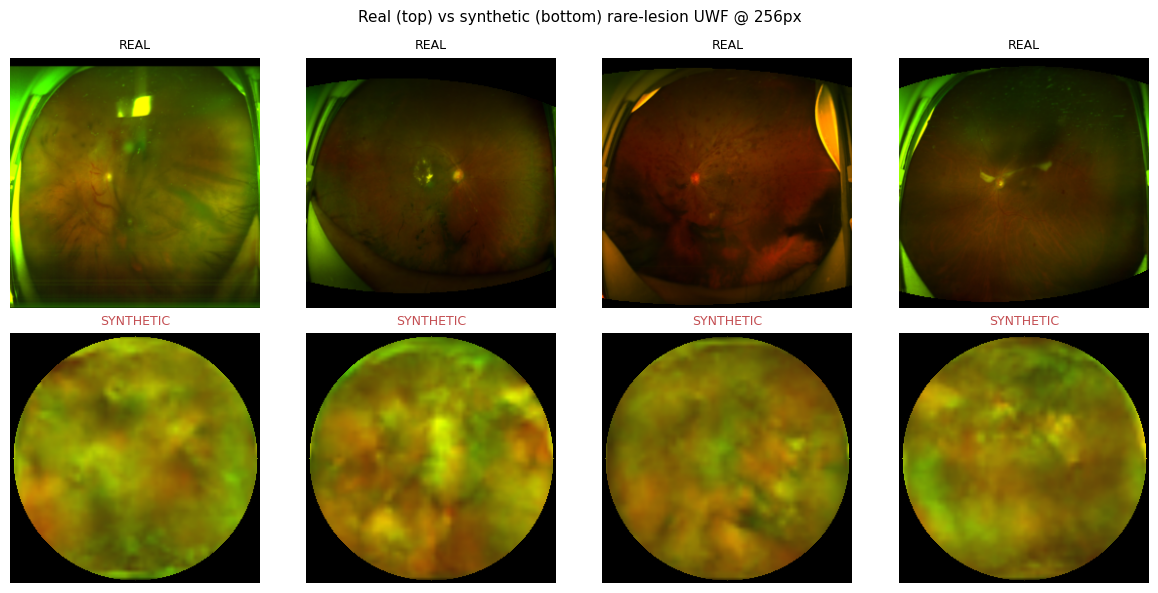

mean pairwise synthetic distance (diversity proxy): 45.614  (near 0 = collapse)


In [32]:
# ==============================================================================
# real-vs-synthetic visual panel + pairwise-diversity (mode-collapse) proxy
# ==============================================================================
import matplotlib.pyplot as plt
R = CONFIG["STUDY_RES"]
real4 = _real_rare_batch(R, k=4)[:4]; syn4 = _synth_batch(R, k=4)[:4]
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    ax[0, i].imshow(real4[i].permute(1,2,0).numpy()); ax[0, i].axis("off"); ax[0, i].set_title("REAL", fontsize=9)
    ax[1, i].imshow(syn4[i].permute(1,2,0).numpy()); ax[1, i].axis("off")
    ax[1, i].set_title("SYNTHETIC", color="#C44E52", fontsize=9)
fig.suptitle(f"Real (top) vs synthetic (bottom) rare-lesion UWF @ {R}px", fontsize=11)
plt.tight_layout(); plt.savefig(os.path.join(DIRS["plots"], "real_vs_synth.png"), dpi=110); plt.show()

syn_flat = _synth_batch(R, k=16).reshape(16, -1)
d = torch.cdist(syn_flat, syn_flat); mask = ~torch.eye(16, dtype=torch.bool)
print(f"mean pairwise synthetic distance (diversity proxy): {d[mask].mean().item():.3f}  (near 0 = collapse)")

In [33]:
# ==============================================================================
# models/classifier.py + training/losses.py -- UWF_SupConDRNet + combined objective (VERBATIM folder-3)
# ==============================================================================
class UWF_SupConDRNet(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1, self.layer2 = resnet.layer1, resnet.layer2
        self.layer3, self.layer4 = resnet.layer3, resnet.layer4
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.proj_early = nn.Sequential(nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, 128))
        self.proj_deep  = nn.Sequential(nn.Linear(2048, 512), nn.ReLU(), nn.Linear(512, 128))
        self.lat_l4 = nn.Conv2d(2048, 512, 1); self.lat_l3 = nn.Conv2d(1024, 512, 1)
        self.lat_l2 = nn.Conv2d(512, 512, 1);  self.lat_l1 = nn.Conv2d(256, 512, 1)
        self.classifier_lesions = nn.Linear(512, 7)
        self.classifier_grade = nn.Linear(512, 5)
    def forward(self, x):
        x = self.stem(x)
        l1 = self.layer1(x); l2 = self.layer2(l1); l3 = self.layer3(l2); l4 = self.layer4(l3)
        z_early = self.proj_early(self.global_pool(l2).flatten(1))
        z_deep  = self.proj_deep(self.global_pool(l4).flatten(1))
        p4 = self.lat_l4(l4)
        p3 = self.lat_l3(l3) + F.interpolate(p4, size=l3.shape[-2:], mode="bilinear", align_corners=False)
        p2 = self.lat_l2(l2) + F.interpolate(p3, size=l2.shape[-2:], mode="bilinear", align_corners=False)
        p1 = self.lat_l1(l1) + F.interpolate(p2, size=l1.shape[-2:], mode="bilinear", align_corners=False)
        pooled = self.global_pool(p1).flatten(1)
        return self.classifier_lesions(pooled), self.classifier_grade(pooled), z_early, z_deep

class AsymmetricFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, beta=(0.7,0.7,0.7,0.8,0.95,0.95,0.95)):
        super().__init__(); self.gamma = gamma
        self.register_buffer("beta", torch.tensor(list(beta), dtype=torch.float32))
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce); focal = (1 - pt) ** self.gamma * bce
        beta = self.beta.to(logits.device)
        return torch.where(targets == 1, beta * focal, (1 - beta) * focal).mean()

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__(); self.temperature = temperature
    def forward(self, features, labels):
        features = F.normalize(features, dim=1)
        sim = torch.matmul(features, features.T) / self.temperature
        sim = sim - sim.max(dim=1, keepdim=True)[0].detach()
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(features.device)
        self_mask = torch.scatter(torch.ones_like(mask), 1,
                                  torch.arange(features.shape[0], device=features.device).view(-1, 1), 0)
        mask = mask * self_mask
        exp_logits = torch.exp(sim) * self_mask
        log_prob = sim - torch.log(exp_logits.sum(1, keepdim=True) + 1e-8)
        denom = mask.sum(1); denom = torch.where(denom == 0, torch.ones_like(denom), denom)
        return (-(mask * log_prob).sum(1) / denom).mean()

def _unwrap(m): return m.module if isinstance(m, nn.DataParallel) else m
print("classifier + losses ready")

classifier + losses ready


In [34]:
# ==============================================================================
# evaluation/metrics.py + thresholds.py -- threshold-aware, rare-focused (VERBATIM folder-3)
# ==============================================================================
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             cohen_kappa_score, confusion_matrix, f1_score, matthews_corrcoef,
                             recall_score, roc_auc_score)

def _binarize(probs, thr):
    probs = np.asarray(probs, dtype=np.float64)
    thr = np.asarray(thr, dtype=np.float64).reshape(1, -1)
    return (probs >= thr).astype(int)

def per_lesion_stats(probs, targets, thresholds):
    probs = np.asarray(probs, dtype=np.float64); y = (np.asarray(targets) > 0.5).astype(int)
    pred = _binarize(probs, thresholds); out = {}
    for j, name in enumerate(LESION_NAMES):
        yj, pj, sj = y[:, j], pred[:, j], probs[:, j]
        tp = int(((pj==1)&(yj==1)).sum()); fp = int(((pj==1)&(yj==0)).sum())
        fn = int(((pj==0)&(yj==1)).sum()); tn = int(((pj==0)&(yj==0)).sum())
        rec = tp/(tp+fn) if (tp+fn) else float("nan"); prec = tp/(tp+fp) if (tp+fp) else float("nan")
        f1 = (2*prec*rec/(prec+rec)) if (prec and rec and prec+rec>0) else 0.0
        try: auroc = roc_auc_score(yj, sj) if len(np.unique(yj))>1 else float("nan")
        except ValueError: auroc = float("nan")
        auprc = average_precision_score(yj, sj) if yj.sum()>0 else float("nan")
        out[name] = {"precision": prec, "recall": rec, "f1": f1, "auroc": auroc,
                     "auprc": auprc, "support": int(yj.sum())}
    return out

def lesion_metrics(probs, targets, thresholds):
    per = per_lesion_stats(probs, targets, thresholds); n = LESION_NAMES
    rare = [n[k] for k in RARE_LESION_IDX]; common = [n[k] for k in COMMON_LESION_IDX]
    return {"per_lesion": per,
            "macro_f1": float(np.mean([per[k]["f1"] for k in n])),
            "macro_auroc": float(np.nanmean([per[k]["auroc"] for k in n])),
            "macro_auprc": float(np.nanmean([per[k]["auprc"] for k in n])),
            "mean_rare_recall": float(np.nanmean([per[k]["recall"] for k in rare])),
            "rare_recall": {k: per[k]["recall"] for k in rare},
            "rare_macro_f1": float(np.mean([per[k]["f1"] for k in rare])),
            "rare_macro_auprc": float(np.nanmean([per[k]["auprc"] for k in rare])),
            "common_macro_f1": float(np.mean([per[k]["f1"] for k in common]))}

def grade_metrics(gp, gt):
    gp, gt = np.asarray(gp), np.asarray(gt)
    return {"accuracy": float(accuracy_score(gt, gp)),
            "quadratic_kappa": float(cohen_kappa_score(gt, gp, weights="quadratic")),
            "balanced_acc": float(balanced_accuracy_score(gt, gp)),
            "confusion_matrix": confusion_matrix(gt, gp, labels=list(range(5))).tolist()}

def _grid(cfg): return np.arange(cfg["thr_min"], cfg["thr_max"]+1e-9, cfg["thr_step"])
def _best_thr(scores, y, grid, obj):
    y = y.astype(int)
    if y.sum()==0 or y.sum()==len(y): return 0.5
    bt, bo = 0.5, -1.0
    for t in grid:
        pred = (scores>=t).astype(int)
        tp=int(((pred==1)&(y==1)).sum()); fp=int(((pred==1)&(y==0)).sum()); fn=int(((pred==0)&(y==1)).sum())
        prec = tp/(tp+fp) if (tp+fp) else 0.0; rec = tp/(tp+fn) if (tp+fn) else 0.0
        o = (2*prec*rec/(prec+rec)) if (prec+rec) else 0.0
        if o>bo: bo, bt = o, float(t)
    return bt
def optimize_thresholds(probs, targets, cfg):
    probs = np.asarray(probs, dtype=np.float64); y = (np.asarray(targets)>0.5).astype(int)
    grid = _grid(cfg)
    return [_best_thr(probs[:, j], y[:, j], grid, cfg["thr_objective"]) for j in range(probs.shape[1])]

def summary_row(gp, gt, lprob, lt, thr):
    lm = lesion_metrics(lprob, lt, thr); gm = grade_metrics(gp, gt)
    return {"mean_rare_recall": lm["mean_rare_recall"],
            "recall_NV": lm["rare_recall"]["NV"], "recall_VH": lm["rare_recall"]["VH"],
            "recall_RD": lm["rare_recall"]["RD"], "rare_macro_f1": lm["rare_macro_f1"],
            "rare_macro_auprc": lm["rare_macro_auprc"], "macro_f1": lm["macro_f1"],
            "grade_qkappa": gm["quadratic_kappa"], "grade_acc": gm["accuracy"],
            "common_macro_f1": lm["common_macro_f1"], "_lesion": lm, "_grade": gm, "_thr": list(thr)}
print("metrics ready")

metrics ready


In [35]:
# ==============================================================================
# data/mixed.py -- SyntheticDataset (no re-mask) + the three regime train loaders
# ==============================================================================
class SyntheticDataset(Dataset):
    '''Already masked+upsampled synthetic -> NO apply_uwf_mask. has_rare hard-coded 1.'''
    def __init__(self, labels_csv, pool_dir, transform, img_size=256):
        self.df = pd.read_csv(labels_csv); self.dir = pool_dir; self.tf = transform; self.sz = img_size
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(os.path.join(self.dir, r["image"])).convert("RGB").resize((self.sz, self.sz))
        les = torch.tensor(parse_lesion(r["lesion"]), dtype=torch.float32)
        return self.tf(img), int(r["grade"]), les, torch.tensor(1.0), i

def build_regime_train_loader(regime, train_tf, cfg):
    sz, bs = cfg["STUDY_RES"], cfg["batch_size"]
    kw = dict(num_workers=cfg["num_workers"], pin_memory=True, drop_last=True)
    real = UWF_Dataset(train_df, IMG_DIR, train_tf, sz)
    if regime == "real":
        return DataLoader(real, batch_size=bs, shuffle=True, **kw)
    if regime == "oversample":
        r = rare_indicator(train_df).to_numpy().astype(float)
        pos = max(r.mean(), 1e-6)
        w = np.where(r == 1, (1 - pos) / pos, 1.0)          # up-weight rare images to ~balance
        sampler = WeightedRandomSampler(torch.as_tensor(w, dtype=torch.double), len(real), replacement=True)
        return DataLoader(real, batch_size=bs, sampler=sampler, **kw)
    if regime == "synth":
        syn = SyntheticDataset(POOL_CSV, POOL_DIR, train_tf, sz)
        return DataLoader(ConcatDataset([real, syn]), batch_size=bs, shuffle=True, **kw)
    raise ValueError(regime)

def build_eval_loaders(cfg):
    _, eval_tf = build_transforms(cfg["STUDY_RES"])
    kw = dict(num_workers=cfg["num_workers"], pin_memory=True)
    vl = DataLoader(UWF_Dataset(val_df, IMG_DIR, eval_tf, cfg["STUDY_RES"]), batch_size=cfg["batch_size"]*2, shuffle=False, **kw)
    tl = DataLoader(UWF_Dataset(test_df, IMG_DIR, eval_tf, cfg["STUDY_RES"]), batch_size=cfg["batch_size"]*2, shuffle=False, **kw)
    return vl, tl
print("regime loaders ready")

regime loaders ready


In [36]:
# ==============================================================================
# training/checkpoint.py -- tag-scoped save/resume + Kaggle Dataset backup (VERBATIM pattern)
# ==============================================================================
import shutil
def _strip(sd):
    return {k[7:]: v for k, v in sd.items()} if sd and all(k.startswith("module.") for k in sd) else sd
def save_ckpt(state, is_best, ckpt_dir, tag):
    os.makedirs(ckpt_dir, exist_ok=True)
    torch.save(state, os.path.join(ckpt_dir, f"last_{tag}.pth"))
    if is_best: torch.save(state, os.path.join(ckpt_dir, f"best_{tag}.pth"))
def find_resume(ckpt_dir, tag):
    loc = os.path.join(ckpt_dir, f"last_{tag}.pth")
    if os.path.exists(loc): return loc
    hits = sorted(glob.glob(f"/kaggle/input/**/last_{tag}.pth", recursive=True), key=os.path.getmtime, reverse=True)
    return hits[0] if hits else None
def load_ckpt(path, model, optimizer=None, device="cpu"):
    if not path or not os.path.exists(path): return 0, float("-inf"), None
    ck = torch.load(path, map_location=device, weights_only=False)
    _unwrap(model).load_state_dict(_strip(ck["state_dict"]))
    if optimizer is not None and ck.get("optimizer"): optimizer.load_state_dict(ck["optimizer"])
    print(f"[*] resumed {path} @ epoch {ck['epoch']} (best {ck.get('best_score',0):.4f})")
    return ck["epoch"], ck.get("best_score", float("-inf")), ck.get("thresholds")
def ensure_kaggle_auth():
    if os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")): return True
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"): return True
    try:
        from kaggle_secrets import UserSecretsClient
        us = UserSecretsClient()
        os.environ["KAGGLE_USERNAME"] = us.get_secret("KAGGLE_USERNAME")
        os.environ["KAGGLE_KEY"] = us.get_secret("KAGGLE_KEY"); return True
    except Exception as e:
        print("   [backup] no Kaggle creds:", str(e)[:90]); return False
def push_to_dataset(cfg, extra_files=(), reason=""):
    if not cfg.get("backup_to_dataset") or not ensure_kaggle_auth(): return
    slug = cfg["backup_dataset_slug"]; wd = os.path.join(cfg["ckpt_dir"], "ckpt_backup"); os.makedirs(wd, exist_ok=True)
    staged = 0
    for src in list(glob.glob(os.path.join(cfg["ckpt_dir"], "*.pth"))) + list(extra_files):
        if os.path.exists(src): shutil.copy(src, os.path.join(wd, os.path.basename(src))); staged += 1
    if staged == 0: return
    with open(os.path.join(wd, "dataset-metadata.json"), "w") as f:
        json.dump({"title": slug.split("/")[-1], "id": slug, "licenses": [{"name": "CC0-1.0"}]}, f)
    ver = subprocess.run(["kaggle","datasets","version","-p",wd,"-m",reason or "auto","--dir-mode","zip"],
                         capture_output=True, text=True)
    if ver.returncode != 0:
        crt = subprocess.run(["kaggle","datasets","create","-p",wd,"--dir-mode","zip"], capture_output=True, text=True)
        ok, out = crt.returncode == 0, (crt.stdout or crt.stderr)
    else: ok, out = True, (ver.stdout or ver.stderr)
    print("   [backup]", "OK" if ok else "FAILED", "->", slug)
print("checkpoint/backup infra ready")

checkpoint/backup infra ready


In [37]:
# ==============================================================================
# training/loop.py -- train ONE (regime, seed); eval on the 100%-real test set
# ==============================================================================
import gc
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k): return x
def run_epoch(model, loader, criteria, optimizer, scaler, cfg, train=True):
    model.train() if train else model.eval()
    afl, sup, ce = criteria
    gp, gt, lp, lt = [], [], [], []; tot, seen = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    pbar = tqdm(loader, total=len(loader), leave=False, desc="train" if train else "val")
    with ctx:
        for x, g, les, rare, _ in pbar:
            x=x.to(device,non_blocking=True); g=g.to(device,non_blocking=True)
            les=les.to(device,non_blocking=True); rare=rare.to(device,non_blocking=True)
            if train: optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=(device.type=="cuda")):
                ol, og, ze, zd = model(x)
                loss = afl(ol, les) + cfg["lambda_grade"]*ce(og, g) \
                       + cfg["lambda_supcon"]*sup(ze, rare) + cfg["lambda_supcon"]*sup(zd, rare)
            if train:
                scaler.scale(loss).backward(); scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
                scaler.step(optimizer); scaler.update()
            tot += float(loss.item())*x.size(0); seen += x.size(0)
            if seen % (x.size(0)*20) == 0:
                try: pbar.set_postfix(loss=f"{tot/max(1,seen):.4f}")
                except Exception: pass
            if not train:
                gp.extend(og.argmax(1).cpu().numpy()); gt.extend(g.cpu().numpy())
                lp.extend(torch.sigmoid(ol.float()).cpu().numpy()); lt.extend(les.cpu().numpy())
    return tot/max(1,seen), gp, gt, np.array(lp), np.array(lt)

def train_regime(regime, seed, cfg, dirs):
    tag = f"{regime}_s{seed}"
    res_json = os.path.join(dirs["results"], f"{tag}.json")
    if os.path.exists(res_json):
        print(f"[skip] {tag} already complete."); return json.load(open(res_json))
    set_seed(seed)
    model = UWF_SupConDRNet().to(device)
    if N_GPU > 1: model = nn.DataParallel(model)
    criteria = (AsymmetricFocalLoss(cfg["afl_gamma"], cfg["afl_beta"]).to(device),
                SupConLoss(cfg["supcon_temperature"]).to(device),
                nn.CrossEntropyLoss(label_smoothing=cfg["grade_label_smoothing"]))
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type=="cuda"))
    train_tf, _ = build_transforms(cfg["STUDY_RES"])
    train_loader = build_regime_train_loader(regime, train_tf, cfg)
    val_loader, test_loader = build_eval_loaders(cfg)

    start, best_score, best_thr = 0, float("-inf"), None
    rp = find_resume(cfg["ckpt_dir"], tag)
    if rp: start, best_score, best_thr = load_ckpt(rp, model, optimizer, device)

    log = os.path.join(dirs["logs"], f"{tag}.csv")
    if not os.path.exists(log):
        open(log,"w").write("epoch,train_loss,val_loss,mean_rare_recall,macro_f1,grade_qkappa,select,sec\n")
    patience = 0
    for epoch in range(start, cfg["epochs"]):
        if time.time() > DEADLINE:
            print(f"[{tag}] time budget reached @ epoch {epoch+1}; will resume next session.")
            push_to_dataset(cfg, [log], f"{tag} budget-stop"); return None
        te = time.time()
        tr_loss, *_ = run_epoch(model, train_loader, criteria, optimizer, scaler, cfg, True)
        va_loss, gp, gt, lp, lt = run_epoch(model, val_loader, criteria, optimizer, scaler, cfg, False)
        thr = optimize_thresholds(lp, lt, cfg)
        lm = lesion_metrics(lp, lt, thr)
        score = cfg["sel_rare_weight"]*lm["mean_rare_recall"] + cfg["sel_f1_weight"]*lm["macro_f1"]
        scheduler.step(va_loss)
        is_best = score > best_score
        if is_best: best_score, best_thr, patience = score, thr, 0
        else: patience += 1
        gm = grade_metrics(gp, gt)
        print(f"[{tag}] ep {epoch+1:02d}/{cfg['epochs']}  val {va_loss:.3f}  "
              f"rare-recall {lm['mean_rare_recall']:.3f}  macro-F1 {lm['macro_f1']:.3f}  "
              f"kappa {gm['quadratic_kappa']:.3f}  (best {best_score:.3f}, pat {patience}/{cfg['patience']})"
              f"{'  <-- BEST' if is_best else ''}")
        open(log,"a").write(f"{epoch+1},{tr_loss:.4f},{va_loss:.4f},{lm['mean_rare_recall']:.4f},"
                            f"{lm['macro_f1']:.4f},{gm['quadratic_kappa']:.4f},{score:.4f},{time.time()-te:.0f}\n")
        save_ckpt({"epoch":epoch+1,"state_dict":_unwrap(model).state_dict(),"optimizer":optimizer.state_dict(),
                   "best_score":best_score,"thresholds":best_thr,"tag":tag}, is_best, cfg["ckpt_dir"], tag)
        if (epoch+1) % 2 == 0 or is_best: push_to_dataset(cfg, [log], f"{tag} ep{epoch+1}")
        if patience >= cfg["patience"]:
            print(f"[{tag}] early stop @ epoch {epoch+1}"); break

    # ---- final eval on the 100%-REAL test set with frozen best thresholds ----
    bp = os.path.join(cfg["ckpt_dir"], f"best_{tag}.pth")
    if os.path.exists(bp): load_ckpt(bp, model, device=device)
    _, gp, gt, lp, lt = run_epoch(model, test_loader, criteria, None, scaler, cfg, False)
    row = summary_row(gp, gt, lp, lt, best_thr or [0.5]*7)
    row.update({"regime": regime, "seed": seed, "tag": tag, "split_signature": SIG,
                "n_syn": len(pd.read_csv(POOL_CSV)) if regime=="synth" else 0})
    json.dump(row, open(res_json,"w"), indent=2, default=float)
    print(f"[{tag}] TEST  rare-recall {row['mean_rare_recall']:.4f}  macro-F1 {row['macro_f1']:.4f}  "
          f"kappa {row['grade_qkappa']:.4f}  common-F1 {row['common_macro_f1']:.4f}")
    push_to_dataset(cfg, [res_json, log], f"{tag} FINAL")
    del model; gc.collect(); torch.cuda.empty_cache()
    return row
print("train_regime ready")

train_regime ready


---
## Run the study

For the preliminary pass this trains **3 regimes × 1 seed** on the frozen split (~4–6 h; fits one Kaggle
session, and resumes if it does not). Each `(regime, seed)` writes its own `results/*.json`, so a re-run
skips finished ones. Set `QUICK_PASS=False` for the full 3-seed × 3-amount protocol.

In [38]:
# ==============================================================================
# 3-REGIME DRIVER
# ==============================================================================
ALL_ROWS = []
for seed in CONFIG["SEEDS"]:
    for regime in CONFIG["REGIMES"]:
        print("\n" + "="*70 + f"\nTRAIN  regime={regime}  seed={seed}\n" + "="*70)
        r = train_regime(regime, seed, CONFIG, DIRS)
        if r is None:
            print(">>> Session budget hit. Attach the checkpoint dataset and Run All to continue.")
            break
        ALL_ROWS.append(r)
    else:
        continue
    break
print(f"\ncompleted {len(ALL_ROWS)} regime-runs")


TRAIN  regime=real  seed=42
[*] resumed /kaggle/working/checkpoints/last_real_s42.pth @ epoch 2 (best 0.7476)


train:   0%|          | 0/227 [00:00<?, ?it/s]

val:   0%|          | 0/25 [00:00<?, ?it/s]

[real_s42] ep 03/22  val 4.907  rare-recall 0.792  macro-F1 0.736  kappa 0.888  (best 0.764, pat 0/8)  <-- BEST
   [backup] OK -> krrish1008/checkpoint-smg-downstream


train:   0%|          | 0/227 [00:00<?, ?it/s]

...

train:   0%|          | 0/261 [00:00<?, ?it/s]

val:   0%|          | 0/25 [00:00<?, ?it/s]

[synth_s42] ep 17/22  val 4.809  rare-recall 0.834  macro-F1 0.755  kappa 0.903  (best 0.808, pat 8/8)
[synth_s42] early stop @ epoch 17
[*] resumed /kaggle/working/checkpoints/best_synth_s42.pth @ epoch 9 (best 0.8079)


val:   0%|          | 0/25 [00:00<?, ?it/s]

[synth_s42] TEST  rare-recall 0.8326  macro-F1 0.6903  kappa 0.8922  common-F1 0.7161
   [backup] OK -> krrish1008/checkpoint-smg-downstream

completed 3 regime-runs


In [39]:
# ==============================================================================
# FINAL COMPARISON TABLE + VERDICT (single seed = descriptive)
# ==============================================================================
import glob as _g
rows = [json.load(open(p)) for p in _g.glob(os.path.join(DIRS["results"], "*_s*.json"))]
seed0 = CONFIG["SEEDS"][0]
by = {r["regime"]: r for r in rows if r["seed"] == seed0}
METRICS = ["mean_rare_recall","recall_NV","recall_VH","recall_RD","rare_macro_f1",
           "rare_macro_auprc","macro_f1","grade_qkappa","common_macro_f1"]

if all(k in by for k in ("real","oversample","synth")):
    tab = pd.DataFrame([{**{"regime":rg}, **{m: by[rg][m] for m in METRICS}}
                        for rg in ("real","oversample","synth")]).set_index("regime")
    print("=== Held-out REAL test set (seed %d) ===" % seed0)
    print(tab[METRICS].round(4).to_string())
    base = tab.loc["real"]
    dtab = (tab[METRICS] - base[METRICS]).round(4)
    print("\nDelta vs real-only:")
    print(dtab.loc[["oversample","synth"]].to_string())

    i, ii, iii = by["real"], by["oversample"], by["synth"]
    beats = (iii["mean_rare_recall"] > i["mean_rare_recall"]) and (iii["mean_rare_recall"] > ii["mean_rare_recall"])
    no_kappa_reg  = iii["grade_qkappa"]    >= i["grade_qkappa"]    - 1e-6
    no_common_reg = iii["common_macro_f1"] >= i["common_macro_f1"] - 1e-6
    VERDICT = beats and no_kappa_reg and no_common_reg
    print("\n" + "="*70)
    print(f"VERDICT -- synthetic augmentation helps: {VERDICT}")
    print(f"  mean rare recall:  synth {iii['mean_rare_recall']:.4f} | real {i['mean_rare_recall']:.4f} "
          f"| oversample {ii['mean_rare_recall']:.4f}")
    print(f"  per-rare (synth):  NV {iii['recall_NV']:.3f}  VH {iii['recall_VH']:.3f}  RD {iii['recall_RD']:.3f}")
    print(f"  guardrails:        grade-kappa {iii['grade_qkappa']:.4f} vs {i['grade_qkappa']:.4f} | "
          f"common-F1 {iii['common_macro_f1']:.4f} vs {i['common_macro_f1']:.4f}")
    print("  SUCCESS = synth beats BOTH real and oversample on rare recall WITHOUT regressing "
          "grade-kappa or common-lesion F1.")
    if len(CONFIG["SEEDS"]) < 3:
        print("  CAVEAT: single-seed (QUICK_PASS) -> descriptive only; no significance claim.")
    json.dump({"table": tab[METRICS].to_dict(), "verdict": bool(VERDICT), "seed": seed0,
               "quality_gate": GATE, "split_signature": SIG, "quick_pass": QUICK_PASS},
              open(os.path.join(DIRS["results"], "verdict_summary.json"), "w"), indent=2, default=float)
    push_to_dataset(CONFIG, [os.path.join(DIRS["results"], "verdict_summary.json")], "verdict summary")
else:
    print("Not all three regimes finished yet -- re-run (with the checkpoint dataset attached) to continue.")

=== Held-out REAL test set (seed 42) ===
            mean_rare_recall  recall_NV  recall_VH  recall_RD  rare_macro_f1  rare_macro_auprc  macro_f1  grade_qkappa  common_macro_f1
regime                                                                                                                                 
real                  0.8776     0.8941     0.9000     0.8387         0.6868            0.6531    0.7073        0.9020           0.7227
oversample            0.8074     0.8059     0.8421     0.7742         0.7138            0.7969    0.7156        0.8802           0.7168
synth                 0.8326     0.8882     0.9000     0.7097         0.6559            0.6648    0.6903        0.8922           0.7161

Delta vs real-only:
            mean_rare_recall  recall_NV  recall_VH  recall_RD  rare_macro_f1  rare_macro_auprc  macro_f1  grade_qkappa  common_macro_f1
regime                                                                                                                    

Significance testing needs >=3 seeds (QUICK_PASS=False). n=1 seed(s): descriptive only.


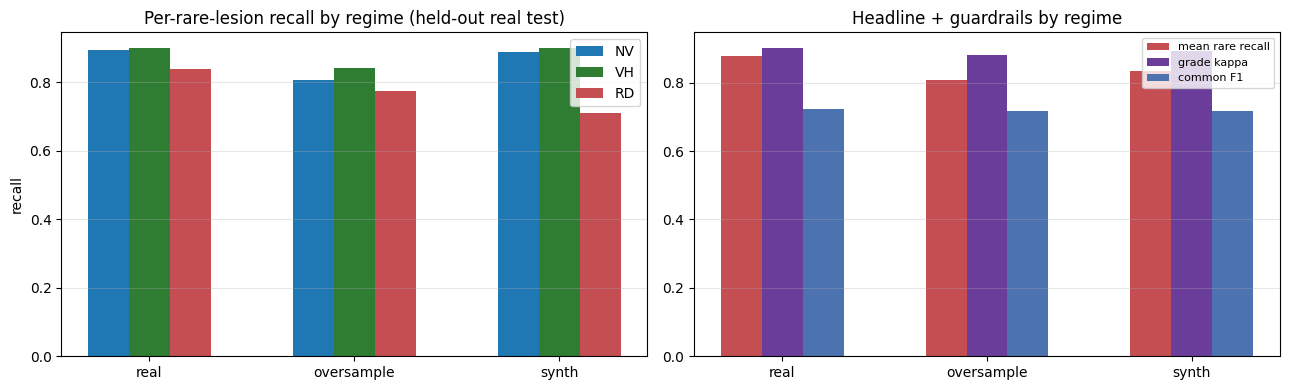

In [40]:
# ==============================================================================
# Significance (>=3 seeds only) + plots
# ==============================================================================
if len(CONFIG["SEEDS"]) >= 3 and len(rows) >= 9:
    from scipy.stats import wilcoxon
    def vec(regime): return np.array([r["mean_rare_recall"] for r in rows if r["regime"]==regime])
    for a in ("real","oversample"):
        try:
            stat, p = wilcoxon(vec("synth"), vec(a))
            print(f"Wilcoxon synth vs {a}: p={p:.4f}")
        except Exception as e:
            print(f"Wilcoxon synth vs {a}: {e}")
else:
    print("Significance testing needs >=3 seeds (QUICK_PASS=False). n=%d seed(s): descriptive only."
          % len(CONFIG["SEEDS"]))

if all(k in by for k in ("real","oversample","synth")):
    regs = ["real","oversample","synth"]; xr = np.arange(3); w = 0.2
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    for off, key, lab, col in [(-w,"recall_NV","NV","#1f77b4"),(0,"recall_VH","VH","#2e7d32"),(w,"recall_RD","RD","#C44E52")]:
        ax[0].bar(xr+off, [by[r][key] for r in regs], w, label=lab, color=col)
    ax[0].set_xticks(xr); ax[0].set_xticklabels(regs); ax[0].set_ylabel("recall"); ax[0].legend()
    ax[0].set_title("Per-rare-lesion recall by regime (held-out real test)"); ax[0].grid(axis="y", alpha=.3)
    for off, key, lab, col in [(-w,"mean_rare_recall","mean rare recall","#C44E52"),
                               (0,"grade_qkappa","grade kappa","#6a3d9a"),
                               (w,"common_macro_f1","common F1","#4C72B0")]:
        ax[1].bar(xr+off, [by[r][key] for r in regs], w, label=lab, color=col)
    ax[1].set_xticks(xr); ax[1].set_xticklabels(regs); ax[1].legend(fontsize=8)
    ax[1].set_title("Headline + guardrails by regime"); ax[1].grid(axis="y", alpha=.3)
    plt.tight_layout(); plt.savefig(os.path.join(DIRS["plots"], "verdict_bars.png"), dpi=120); plt.show()

---
## How to read this result

**The verdict line is the answer to your professor's question:** it states, in one place, whether the
generated data actually improved rare-lesion detection over both a real-only baseline and simple
oversampling, on data the model never trained on.

**Honest limitations, surfaced in the output above.**
1. **64→256 resolution gap** — the FID/KID gate reports the synthetic-vs-real distance at both the
   generator's native 64px and the study's 256px; the gap between them is the upsampling-blur penalty.
   Any recall gain must be weighed against it.
2. **Tiny 3.86M generator** — the diversity proxy and KID guard against mode collapse; a real-vs-synthetic
   probe classifier would confirm the model is not shortcutting on a synthetic fingerprint (the verdict is
   validated only on the 100%-real test set, which prevents that).
3. **Single seed (preliminary)** — no significance is claimed; `QUICK_PASS=False` runs the full
   3-seed × {0.5,1,2}× protocol with a Wilcoxon test, unchanged.
4. **Inherited labels** — each synthetic image borrows a real rare-positive's grade+lesion vector
   (`donor_idx` recorded in `labels.csv`); the grade/common channels are weak supervision, which is exactly
   why the verdict requires no grade-kappa or common-F1 regression.

**A negative result is still a result.** If synthetic augmentation at 64px does not beat oversampling,
that is a legitimate finding — it says the proof-of-concept generator is not yet good enough and motivates
the higher-resolution latent-diffusion generator as the next step.